In [7]:
import torch
from torch import nn
from jaxtyping import Float

In [8]:
def make_gaussian_data(location: tuple[int, int], count: int, std: float, mean: float, label: int) -> Float[torch.Tensor, "count 3"]:
    center = torch.tensor(location)
    gaussian = torch.randn(count, 2) * std + mean + center
    labels = torch.full((count, 1), label)
    return torch.cat([gaussian, labels], dim=1)

cluster_1 = make_gaussian_data((2, 2), 200, 1.0, 1.0, 0)
cluster_2 = make_gaussian_data((-2, -2), 200, 1.0, 1.0, 1)

data = torch.cat([cluster_1, cluster_2], dim=0)

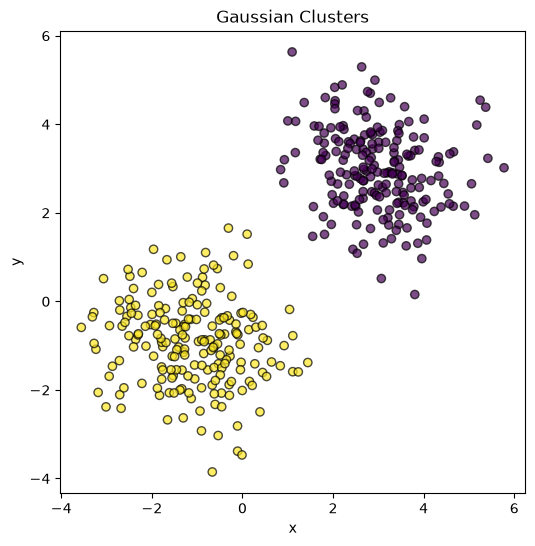

In [9]:
import matplotlib.pyplot as plt

data_np = data.numpy()

plt.figure(figsize=(6, 6))
plt.scatter(data_np[:, 0], data_np[:, 1], c=data_np[:, 2], alpha=0.7, edgecolors="k")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Gaussian Clusters")
plt.show()

In [ ]:
class MLP(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.fc1 = nn.Linear(2, 16)
        self.fc2 = nn.Linear(16, 2)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x
    
model = MLP()
output = model(torch.randn(1,2))
output

tensor([[-0.3239, -0.1270]], grad_fn=<AddmmBackward0>)